# AI 212 [First Group Machine Problem - S2]
# 3. Demonstrating the Central Limit Theorem (CLT)

## Section 1: Behavior of Sample Mean and Median
**Objective:**

Select at least three different types of continuous distributions that are symmetric with
respect to the mean (e.g., uniform, normal, Student t) and draw repeated random samples
from each. Compute and plot the distribution of the sample mean and sample median as
the sample size increases. Discuss how the shape of these distributions changes and why.

### **Overview**
The following script simulates sampling from three different probability distributions:

1. Normal(0,1)
2. Student's t-distribution with df=3
3. Uniform (-1,1)

For each distribution, the script:
- Draws multiple random samples of different sizes. (num_simulations = 1000, sample_sizes = [5, 10, 20, 30, 100, 200])
- Computes the sample means and medians.
- Plots histograms of sample means and medians.
- Generates Q-Q plots to assess normality.
- Computes and visualizes skewness and kurtosis.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from IPython.display import display

#Seed for reproducibility
np.random.seed(42)

#Generate a normal distribution (mean=0, std=1)
def normal_dist(size):
    return np.random.normal(0,1,size)

#Generate a Student's t-distribution with df=3
def student_t_dist(size):
    return np.random.standard_t(df=3, size=size)

#Generate a uniform distribution between -1 and 1
def uniform_dist(size):
    return np.random.uniform(-1, 1, size)


#Plot histograms of sample means and medians
def plot_histograms(distribution, sample_means, sample_medians, sample_sizes):
    figures = {}
    num_samples = len(sample_means)

    # Determine the x-axis limits based on the smallest sample size
    num_sizes = len(sample_sizes)
    colors = plt.cm.tab10.colors[:num_sizes]
    x_min, x_max = min(sample_means[0]), max(sample_means[0])

     # Create subplots for visualizing distributions
    fig1, axes = plt.subplots(2, num_samples//2, figsize=(3.5 * (num_samples // 2), 3.5 * 2))
    axes = axes.flatten()
    fig1.suptitle(f"Sample Means & Medians Distribution ({distribution})", fontsize=14)

    for i, (sample_mean, sample_median) in enumerate(zip(sample_means, sample_medians)):
        # Plot histogram for Sample Means
        axes[i].hist(sample_mean, bins=30, alpha=0.6, edgecolor="black", color="#1f77b4", label="Sample Mean")
        # Plot histogram for Sample Medians
        axes[i].hist(sample_median, bins=30, alpha=0.5, edgecolor="black", color="#ff7f0e", label="Sample Median")

        axes[i].set_title(f"n = {sample_sizes[i]}")
        axes[i].set_xlabel("Value")
        axes[i].legend()
        axes[i].set_xlim(x_min, x_max)

    axes[0].set_ylabel("Frequency")
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # Store sample mean and median histograms
    figures["mean_median"] = fig1
    plt.close(fig1)

    return figures


# Plot QQ plots to assess normality
def plot_qq(distribution, sample_means, sample_medians, sample_sizes):
    figures = {}  # Dictionary to store figures
    num_samples = len(sample_means)
    fig, axes = plt.subplots(2, num_samples//2, figsize=(3.5 * (num_samples // 2), 3.5 * 2))
    axes = axes.flatten()

    for i, sample_mean in enumerate(sample_means):
        # Q-Q Plot for Sample Means
        stats.probplot(sample_mean, dist="norm", plot=axes[i])
        axes[i].get_lines()[1].set_color('blue')  # Line of best fit for means

        # Q-Q Plot for Sample Medians
        stats.probplot(sample_medians[i], dist="norm", plot=axes[i])
        axes[i].get_lines()[3].set_color('red')  # Line of best fit for medians
        axes[i].get_lines()[2].set_color('red')  # Scatter points (medians)

        axes[i].set_title(f"Sample Size {sample_sizes[i]}")
        axes[i].set_xlabel("Theoretical Quantiles")
        axes[i].set_ylabel("Sample Quantiles")
        axes[i].scatter([], [], color='blue', label="Mean")
        axes[i].scatter([], [], color='red', label="Median")
        axes[i].legend()

    fig.suptitle(f"Q-Q Plots for {distribution}", fontsize=16)
    plt.tight_layout()

    # Store the Q-Q figures
    figures["qq"] = fig
    plt.close(fig)

    return figures


# Compute skewness and kurtosis for sample means and medians
def compute_skewness_kurtosis(distribution, sample_means, sample_medians, sample_sizes):
    skewness_mean =[]
    skewness_median =[]

    kurtosis_mean=[]
    kurtosis_median=[]
    for i, sample_mean in enumerate(sample_means):
        skewness_mean.append(stats.skew(sample_mean))
        kurtosis_mean.append(stats.kurtosis(sample_mean, fisher=True) + 3)  # Normality reference value of 3

        skewness_median.append(stats.skew(sample_medians[i]))
        kurtosis_median.append(stats.kurtosis(sample_medians[i], fisher=True) + 3)  # Normality reference value of 3

    return skewness_mean, skewness_median, kurtosis_mean, kurtosis_median


# Plot trends of skewness and kurtosis
def plot_skewness_kurtosis(distribution, sk_mean, kt_mean, sk_median, kt_median, sample_sizes):
    figures = {}
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(f"Skewness & Kurtosis of Sample Means and Medians ({distribution})", fontsize=14)

    # Plot Skewness
    axes[0].plot(sample_sizes, sk_mean, marker="o", linestyle="-", color="blue", label="Skewness (Mean)")
    axes[0].plot(sample_sizes, sk_median, marker="s", linestyle="--", color="orange", label="Skewness (Median)")
    axes[0].axhline(y=0, color="black", linestyle="dotted", linewidth=1)  # Reference line at 0
    axes[0].set_title(f"Skewness vs Sample Size")
    axes[0].set_xlabel("Sample Size")
    axes[0].set_ylabel("Skewness")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.6)

    # Plot Kurtosis
    axes[1].plot(sample_sizes, kt_mean, marker="o", linestyle="-", color="blue", label="Kurtosis (Mean)")
    axes[1].plot(sample_sizes, kt_median, marker="s", linestyle="--", color="orange", label="Kurtosis (Median)")
    axes[1].axhline(y=3, color="black", linestyle="dotted", linewidth=1)  # Reference line at Normal Dist (3)
    axes[1].set_title(f"Kurtosis vs Sample Size")
    axes[1].set_xlabel("Sample Size")
    axes[1].set_ylabel("Kurtosis")
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # Store skewness and kurtosis figures
    figures["skew_kurtosis"] = fig
    plt.close(fig)

    return figures

# Simulation parameters
num_simulations = 1000 #number of repeated samples
sample_sizes = [5,10,20,30,100,200]

distributions ={
    "Normal(0,1)": normal_dist,
    "Student's t(df=3)": student_t_dist,
    "Uniform(-1,1)": uniform_dist
}

# Dictionary to store results
results = {dist_name: {"means":[], "medians": []} for dist_name in distributions}

# Generate sample means and medians
for dist_name, dist_value in distributions.items():
    #Each list of means and medians pertains to each sample_size
    for size in sample_sizes:
        means_per_n = []
        medians_per_n = []
        #Num_simulations = num of means_per_n elements
        for _ in range(num_simulations):
            samples = dist_value(size)
            means_per_n.append(np.mean(samples))
            medians_per_n.append(np.median(samples))
        results[dist_name]["means"].append(means_per_n)
        results[dist_name]["medians"].append(medians_per_n)

# Generate and store figures
stored_figures= {}
stored_values ={}
for dist_name, dist_value in results.items():
    stored_figures[dist_name] = plot_histograms(dist_name, dist_value["means"], dist_value["medians"], sample_sizes)
    sk_mean, sk_median, kt_mean, kt_median = compute_skewness_kurtosis(dist_name, dist_value["means"], dist_value["medians"], sample_sizes)
    stored_figures[dist_name].update(plot_qq(dist_name, dist_value["means"], dist_value["medians"], sample_sizes))
    stored_figures[dist_name].update(plot_skewness_kurtosis(dist_name, sk_mean, kt_mean, sk_median, kt_median, sample_sizes))
    stored_values.update({dist_name: { "sk_mean": sk_mean, "sk_median": sk_median, "kt_mean": kt_mean, "kt_median": kt_median}})

### Normal Distribution

The figure illustrates the empirical distributions of sample means and sample medians derived from repeated sampling (1,000 iterations) of a standard normal distribution, N(0,1), across various sample sizes (n=5,10,20,30,100,200).

The normal distribution is inherently symmetric and bell-shaped, centered at 0 with a standard deviation of 1. Because of this symmetry, both the mean and median of the population are equal. However, when we draw samples of finite size, their sample statistics (means and medians) exhibit variability.
\
For smaller sample sizes  (n = 5, 10, 20), the sample mean and sample median distributions show a wider spread, showing variability due to small sample fluctuations. For larger sample sizes (n = 30, 100, 200), both distributions become tighter and more concentrated around the true population mean (0), consistent with the Law of Large Numbers. The sample mean becomes sharply peaked around 0, indicating lower variance.

The sample median follows a similar trend but has slightly more spread due to its higher resistance to outliers.  
\
While CLT states that the sampling distribution of the sample mean approaches normality as n increases, in this case, the original population is already normally distributed.

Since the normal distribution is already normally distributed, the Central Limit Theorem (CLT) does not significantly change its shape—the sample mean remains normal for all sample sizes. What we observe with increasing n is not a shape transformation (as CLT implies for non-normal populations), but rather a concentration around the mean, i.e., reduced standard error.

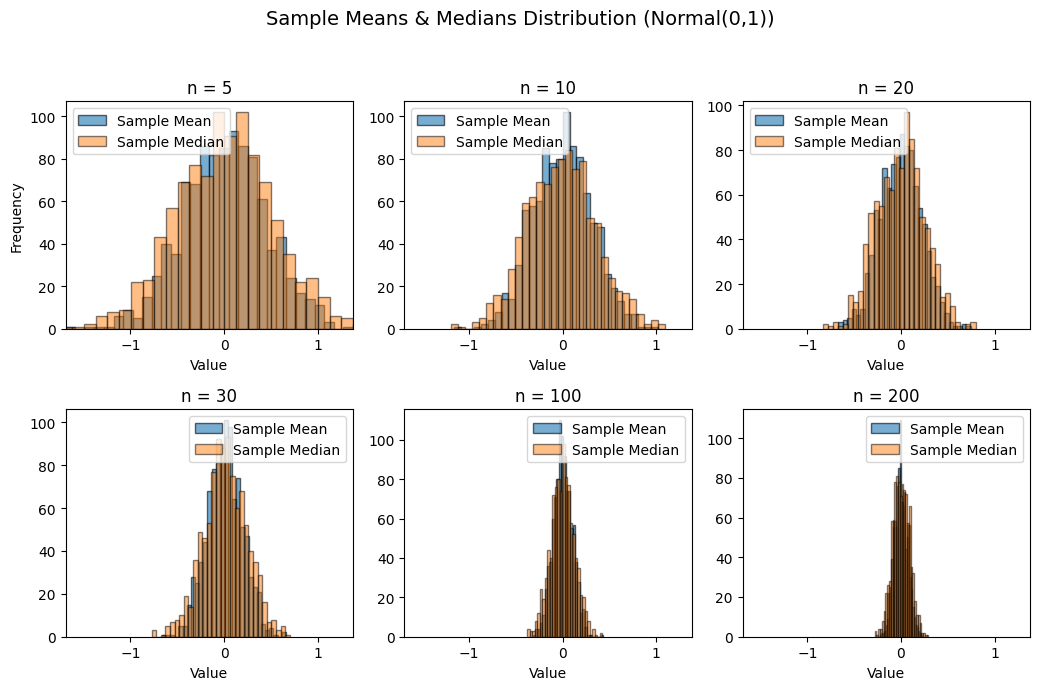

In [2]:
display(stored_figures["Normal(0,1)"]["mean_median"])

### Student's t Distribution

The figure displays the sampling distributions of sample means and sample medians generated from a Student's t-distribution with 3 degrees of freedom, using 1,000 repeated samples for each sample size (n=5,10,20,30,100,200).
The t-distribution with 3 degrees of freedom has heavier tails than the normal distribution, meaning it allows for more extreme values. The mean is still 0, but the variance is larger than that of a normal distribution.  
\
The following figure shows that for smaller sample sizes (n=5,10,20), the sample mean displays high variability. Notably, for very small samples (n=5), the distribution exhibits a slightly heavier left tail, suggesting the influence of extreme negative observations that skew the mean leftward. The sample median is more stable than the mean since it is less sensitive to outliers.
\
For larger sample sizes (n = 30, 100, 200), the sample mean starts to look more like a normal distribution due to the Central Limit Theorem (CLT), but it converges slower than in the normal case because of the heavy tails. The sample median remains slightly wider than the sample mean but follows the same overall trend.  
\
The CLT still applies, but since the original distribution is heavy-tailed, we need larger sample sizes for the mean to approximate normality which we will show numerically in the succeeding section.

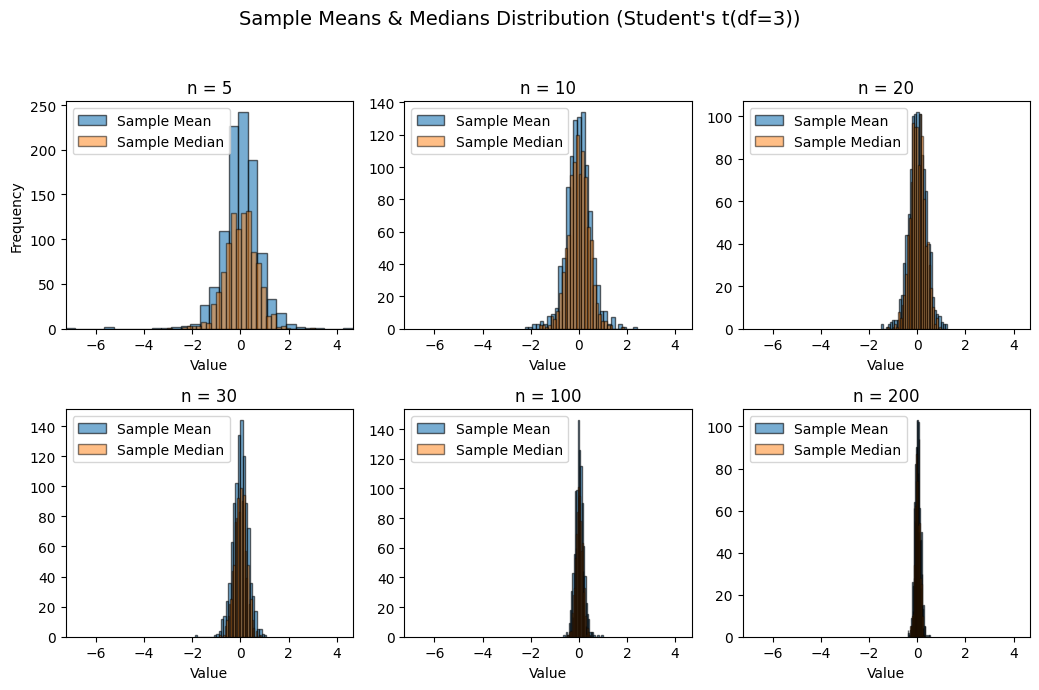

In [3]:
display(stored_figures["Student's t(df=3)"]["mean_median"])

### Uniform Distribution

The uniform distribution is flat and bounded within [−1, 1], meaning it lacks heavy tails or extreme values. Both the population mean and median are 0, but their sampling distributions may vary due to the uniform spread of data.


The succeeding figure highlights that for smaller sample sizes (n = 5, 10, 20), the sample mean and median distributions are wider because samples can be drawn from anywhere in the [−1,1] range. While the median is less influenced by extreme values, it tends to converge more slowly to a tighter distribution than the sample mean, which results in a wider spread even at larger sample sizes.
\
For larger sample sizes (n = 30, 100, 200), the sample mean and sample median starts resembling a normal distribution, in accordance with the CLT.  
\
The uniform distribution is not inherently normal or bell-shaped, but this demonstrates that CLT still applies, ensuring that as 𝑛→∞, the distribution of the sample mean approaches normality.  


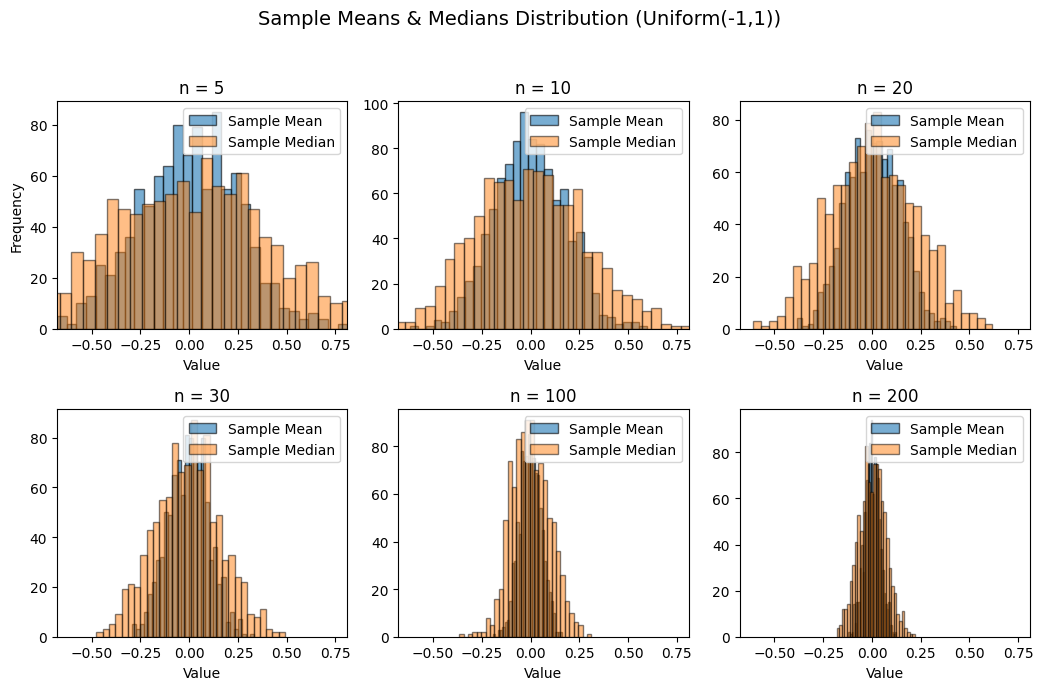

In [4]:
display(stored_figures["Uniform(-1,1)"]["mean_median"])

## Section 2: Q-Q Plots, Skewness, and Kurtosis
**Objective:**

Show that regardless of the original distribution, the sample mean and sample median
tend to be normally distributed as the sample size increases. Use quantile-quantile (QQ)
plots to visually confirm normality and calculate skewness and/or kurtosis to provide
numerical justification.

### Normal Distribution

The Q-Q plots visually support the Central Limit Theorem (CLT) by showing that as sample size increases, the sample mean and sample median increasingly resemble the normal distribution as sample size grows.

The following Q-Q plots for normal distribution across varying sample sizes show that sample means and medians closely follow the theoretical normal quantiles, even for small sample sizes. As sample size increases, the alignment with the normal Q-Q line becomes even tighter.

Since the underlying distribution here is already normal (𝑁(0,1)), both statistics begin close to normality, even for small sample sizes like 5 and 10, which is shown from how close the ploted points align with the diagonal reference line.

Since the original distribution is already normal, the CLT is trivially satisfied, and both statistics exhibit minimal deviations from normality across all sample sizes.

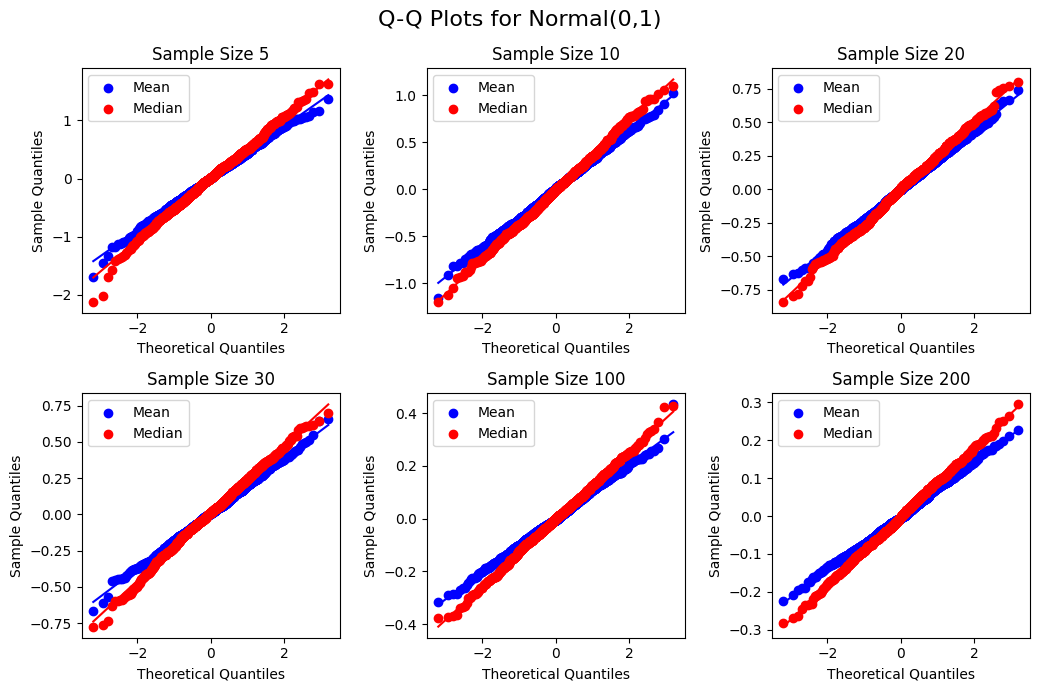

In [5]:
display(stored_figures["Normal(0,1)"]["qq"])

Skewness measures the asymmetry of a distribution, while kurtosis quantifies the heaviness of the tails relative to a normal distribution. A normal distribution has a skewness of 0 and a kurtosis of 3.  

The following figure shows the skewness and kurtosis trend of sample means and medians (Normal(0,1)) for varying sample sizes.  
\
Skewness:

Sample means: Values fluctuate near zero, ranging from (-0.0926 to 0.1049), indicating approximate symmetry.

Sample medians: Similar behavior, staying close to zero (-0.1009 to 0.0015), showing no strong skew.  
\
Kurtosis:

Sample means: Stays close to 3 (ranging from 2.8719 to 3.0594), confirming normality.

Sample medians: Slightly higher values (2.8803 to 3.3066), but still close to 3.  
\
Conclusion: Since the original distribution is normal, both statistics behave as expected, confirming the CLT trivially.

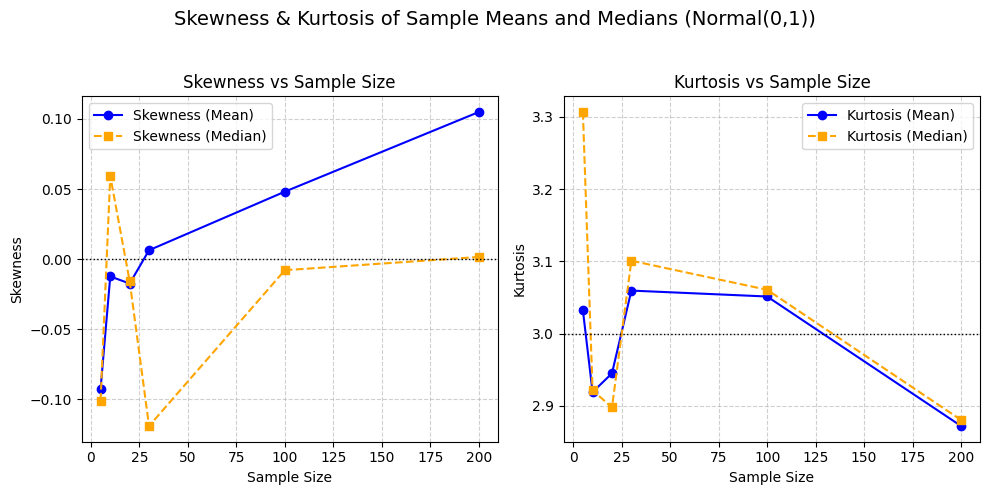

Skewness for Normal(0,1):
n=5: Sample Mean=-0.0926, Sample Median=-0.1009
n=10: Sample Mean=-0.0124, Sample Median=0.0593
n=20: Sample Mean=-0.0174, Sample Median=-0.0158
n=30: Sample Mean=0.0063, Sample Median=-0.1191
n=100: Sample Mean=0.0481, Sample Median=-0.0079
n=200: Sample Mean=0.1049, Sample Median=0.0015

Kurtosis for Normal(0,1):
n=5: Sample Mean=3.0324, Sample Median=3.3066
n=10: Sample Mean=2.9189, Sample Median=2.9215
n=20: Sample Mean=2.9449, Sample Median=2.8977
n=30: Sample Mean=3.0594, Sample Median=3.1008
n=100: Sample Mean=3.0512, Sample Median=3.0605
n=200: Sample Mean=2.8719, Sample Median=2.8803


In [6]:
display(stored_figures["Normal(0,1)"]["skew_kurtosis"])

print(f"Skewness for Normal(0,1):")
[print(f"n={n}: Sample Mean={sk_mean:.4f}, Sample Median={sk_median:.4f}") for n, sk_mean, sk_median in zip(sample_sizes, stored_values["Normal(0,1)"]["sk_mean"], stored_values["Normal(0,1)"]["sk_median"])]
print(f"\nKurtosis for Normal(0,1):")
[print(f"n={n}: Sample Mean={kt_mean:.4f}, Sample Median={kt_median:.4f}") for n, kt_mean, kt_median in zip(sample_sizes, stored_values["Normal(0,1)"]["kt_mean"], stored_values["Normal(0,1)"]["kt_median"])] ; None

### Student's t Distribution

For small sample sizes (n= 5, 10, 20), there is noticeable deviation from normality, especially in the tails for sample mean. The heavy tails of the t-distribution cause the sample mean to exhibit more variability (as seen in the Q-Q plots) due to it being less robust to extreme values than sample median. However, as sample size increases (n= 100, 200), both the sample means and medians approximate normality much better, confirming the CLT.

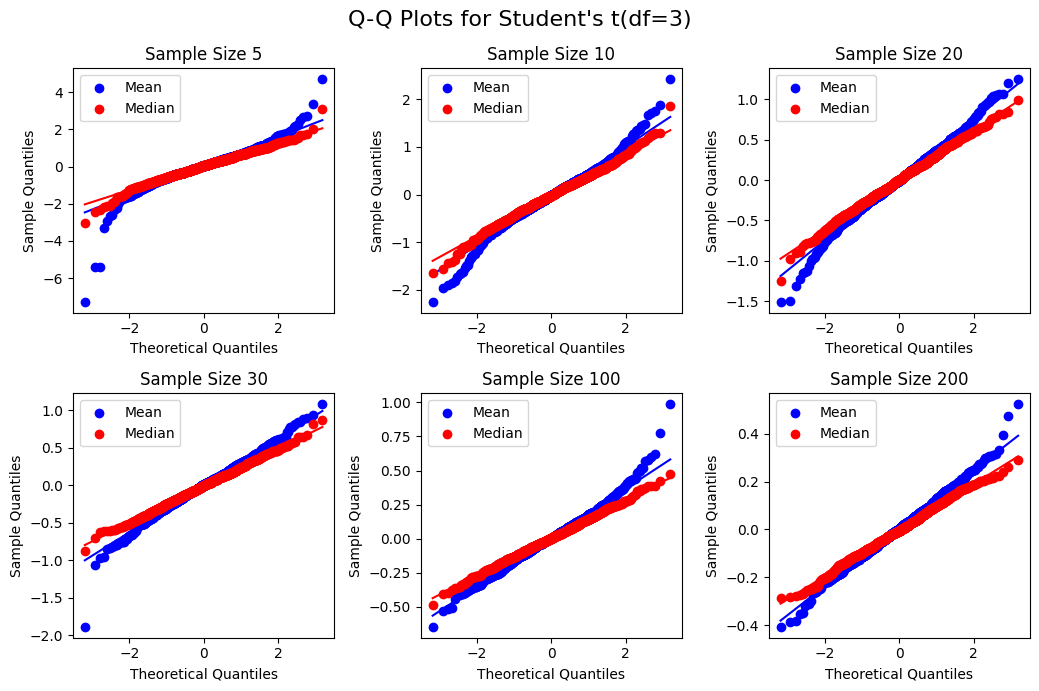

In [7]:
display(stored_figures["Student's t(df=3)"]["qq"])

Skewness:

Sample means: Highly skewed for small samples (-1.1236 for
n=5), improving as n increases (0.1004 for n=200).

Sample medians: Less skewed than means, ranging from -0.2388 to -0.0516.  
\
Kurtosis:

Sample means: Starts very high (14.4548 for n=5), decreasing toward normality (3.4736 at n=200).

Sample medians: More stable, decreasing from 4.2777 (n=5) to 2.9385 (n=200) approaching normality.  
\
Conclusion:

Sample means show strong tail effects initially but stabilize toward normality.

Sample medians provide a more robust alternative with less extreme kurtosis/skewness.

CLT holds, but mean normality emerges at larger sample sizes.

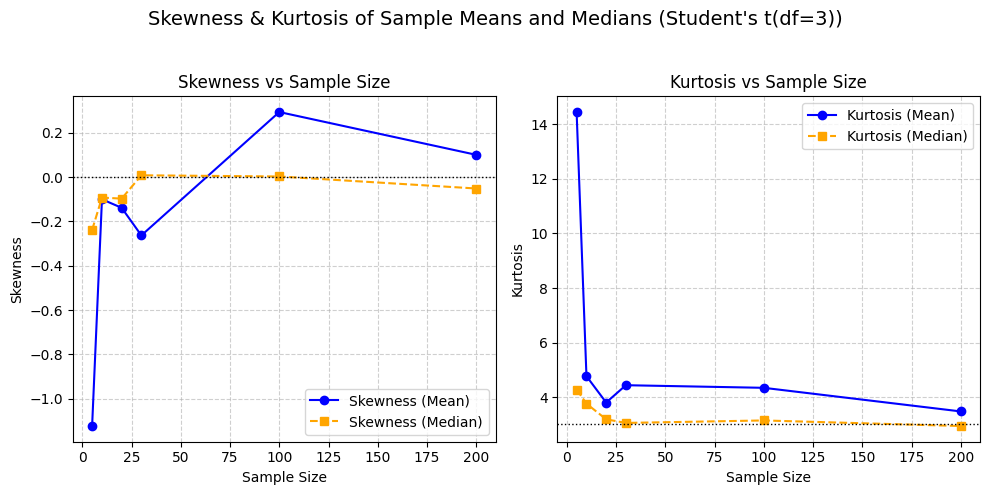

Skewness for Student's t(df=3):
n=5: Sample Mean=-1.1236, Sample Median=-0.2388
n=10: Sample Mean=-0.1002, Sample Median=-0.0925
n=20: Sample Mean=-0.1388, Sample Median=-0.0973
n=30: Sample Mean=-0.2634, Sample Median=0.0080
n=100: Sample Mean=0.2936, Sample Median=0.0027
n=200: Sample Mean=0.1004, Sample Median=-0.0516

Kurtosis for Student's t(df=3):
n=5: Sample Mean=14.4548, Sample Median=4.2777
n=10: Sample Mean=4.7665, Sample Median=3.7593
n=20: Sample Mean=3.8004, Sample Median=3.1845
n=30: Sample Mean=4.4354, Sample Median=3.0521
n=100: Sample Mean=4.3399, Sample Median=3.1427
n=200: Sample Mean=3.4736, Sample Median=2.9385


In [8]:
display(stored_figures["Student's t(df=3)"]["skew_kurtosis"])

print(f"Skewness for Student's t(df=3):")
[print(f"n={n}: Sample Mean={sk_mean:.4f}, Sample Median={sk_median:.4f}") for n, sk_mean, sk_median in zip(sample_sizes, stored_values["Student's t(df=3)"]["sk_mean"], stored_values["Student's t(df=3)"]["sk_median"])]
print(f"\nKurtosis for Student's t(df=3):")
[print(f"n={n}: Sample Mean={kt_mean:.4f}, Sample Median={kt_median:.4f}") for n, kt_mean, kt_median in zip(sample_sizes, stored_values["Student's t(df=3)"]["kt_mean"], stored_values["Student's t(df=3)"]["kt_median"])] ; None

### Uniform Distribution

Small sample sizes (n= 5, 10, 20) show noticeable curvature in the Q-Q plots, especially for the medians.
The sample mean starts aligning with normality much earlier compared to the median as well, which is consistent from the histogram interpretation in the previous section wherein we saw that while the median is less influenced by extreme values, it tends to converge more slowly to a tighter distribution than the sample mean, which results in a wider spread even at larger sample sizes.

 For larger sample sizes (n= 100, 200), both the sample means and medians become approximately normal, aligning well with the theoretical quantiles.

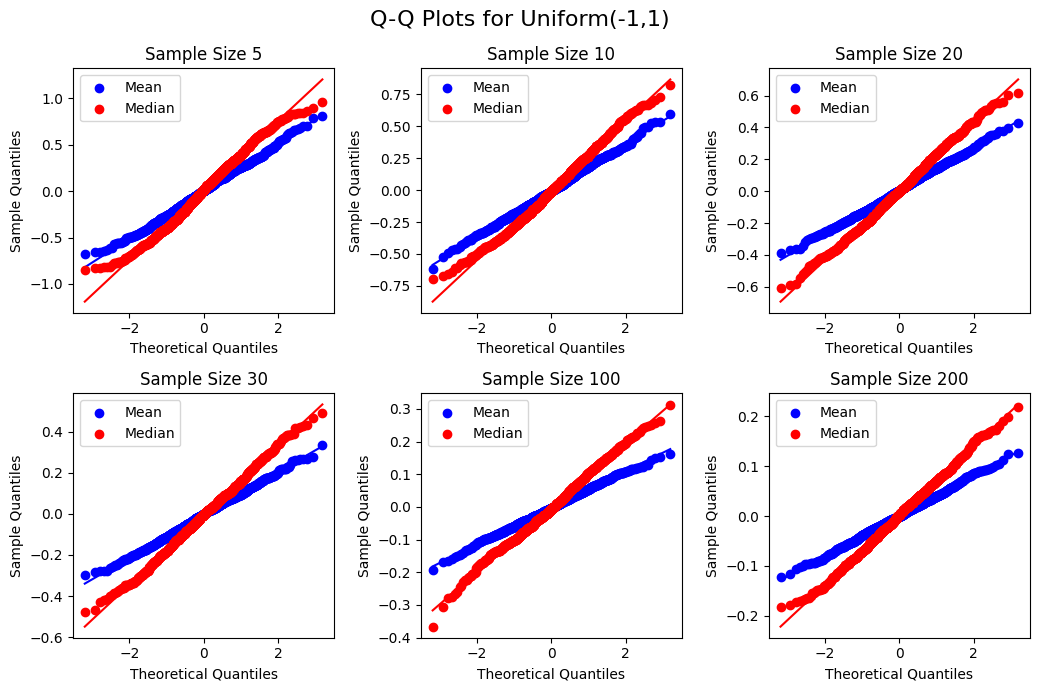

In [9]:
display(stored_figures["Uniform(-1,1)"]["qq"])

Skewness:

Sample means: Small values, fluctuating between -0.0276 and 0.0630.

Sample medians: Slightly larger values (0.0267 to 0.1615) but still relatively small.  
\
Kurtosis:

Sample means: Remains close to 3 but slightly lower (2.7241 –2.9848).

Sample medians: Starts lower (2.3472 for n=5) and gradually approaches 3 (closest at 2.9037 for n=100).  
\
Conclusion:

The sample mean becomes approximately normal as n increases.

The median shows some deviation in kurtosis at small n but approaches normality as well.

Hence, we show that CLT holds as well for uniform distribution.

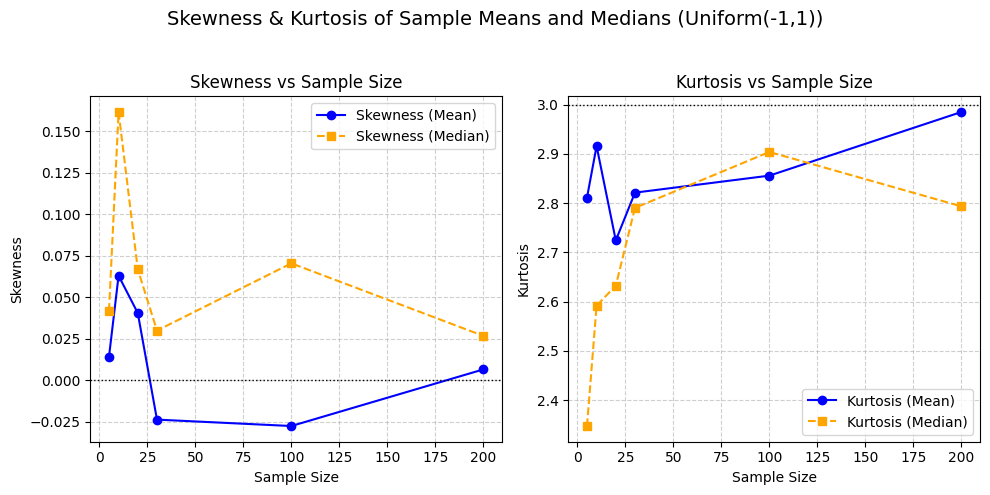

Skewness for Uniform(-1,1):
n=5: Sample Mean=0.0142, Sample Median=0.0418
n=10: Sample Mean=0.0630, Sample Median=0.1615
n=20: Sample Mean=0.0404, Sample Median=0.0668
n=30: Sample Mean=-0.0237, Sample Median=0.0299
n=100: Sample Mean=-0.0276, Sample Median=0.0704
n=200: Sample Mean=0.0065, Sample Median=0.0267

Kurtosis for Uniform(-1,1):
n=5: Sample Mean=2.8109, Sample Median=2.3472
n=10: Sample Mean=2.9156, Sample Median=2.5916
n=20: Sample Mean=2.7241, Sample Median=2.6322
n=30: Sample Mean=2.8211, Sample Median=2.7901
n=100: Sample Mean=2.8556, Sample Median=2.9037
n=200: Sample Mean=2.9848, Sample Median=2.7933


In [10]:
display(stored_figures["Uniform(-1,1)"]["skew_kurtosis"])

print(f"Skewness for Uniform(-1,1):")
[print(f"n={n}: Sample Mean={sk_mean:.4f}, Sample Median={sk_median:.4f}") for n, sk_mean, sk_median in zip(sample_sizes, stored_values["Uniform(-1,1)"]["sk_mean"], stored_values["Uniform(-1,1)"]["sk_median"])]
print(f"\nKurtosis for Uniform(-1,1):")
[print(f"n={n}: Sample Mean={kt_mean:.4f}, Sample Median={kt_median:.4f}") for n, kt_mean, kt_median in zip(sample_sizes, stored_values["Uniform(-1,1)"]["kt_mean"], stored_values["Uniform(-1,1)"]["kt_median"])] ; None

## Section 3:  Efficiency of Sample Mean and Median as Estimators
**Objective:**
Compare the behavior of the sample mean as an estimator for different distributions. Specifically, demonstrate that the sample mean is a good estimator for normally distributed random variables but may not be robust for heavy-tailed distributions such as the the Student t. Discuss why the sample mean fails in heavy-tailed cases and suggest alternative estimators that might be more robust (e.g., trimmed sample mean, sample median).

The following script computes and visualizes the efficiency of the sample mean and sample median as estimators for the location parameter of a Student's t-distribution with varying degrees of freedom (k). Efficiency is measured as the ratio of the Cramér-Rao Lower Bound (CRLB) to the variance of each estimator. A higher efficiency value indicates a better estimator.   
\
The plot compares how the efficiency of the sample mean and
median change as k increases, highlighting the robustness of the median in heavy-tailed distributions.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma

# Sample size
n = 100

# Range of degrees of freedom (k) for Student's t-distribution
k_values = np.arange(3, 21)

# Variance of sample mean for Student's t-distribution
var_mean = k_values / (n * (k_values - 2))

# Variance of sample median for Student's t-distribution
var_median = (1 / (4 * n)) * (k_values * np.pi) * (gamma(k_values / 2) / gamma((k_values + 1) / 2)) ** 2

# CRLB for Student's t-distribution
crlb = (k_values + 3) / (n * (k_values + 1))

# Compute efficiencies
eff_mean = crlb / var_mean
eff_median = crlb / var_median

# Plot the efficiency of sample mean and median
fig_efficiency = plt.figure(figsize=(8, 5))
plt.plot(k_values, eff_mean, label="Mean Efficiency", marker='o', linestyle='-')
plt.plot(k_values, eff_median, label="Median Efficiency", marker='s', linestyle='--', color='red')
plt.xlabel("Degrees of Freedom (k)")
plt.ylabel("Efficiency (CRLB / Variance)")
plt.title(f"Efficiency of Sample Mean & Median (n={n})")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(k_values)
plt.close(fig_efficiency)

The efficiency plot shows that the sample mean is highly efficient when the data follows a normal distribution (increasing k for Student's t distribution). This aligns with statistical theory, as the sample mean is the best unbiased estimator for normal distributions due to its minimum variance property.

The plot demonstrates that the mean efficiency increases as the degrees of freedom (k) rise from 3 to 20, whereas the median efficiency decreases, with the median efficiency only higher than that of the mean for k = 3 and k = 4.

The efficiency of the sample mean decreases for small k (Student’s t with low degrees of freedom), indicating that it is more variable and sensitive to extreme values. As k decreases, the distribution becomes more heavy-tailed, which introduces large outliers that distort the sample mean. Heavy-tailed distributions have long tails with outliers that are much farther from the center (mean) of the distribution compared to normal distributions. The sample mean is the average of all values in the sample. Since it is a linear estimator, the presence of extreme outliers causes the sample mean to shift significantly toward these values, which in effect lowers its efficiency as estimator for these cases given the deviation in its variance.

The Cramér-Rao Lower Bound (CRLB) serves as a theoretical benchmark for the lowest possible variance of an unbiased estimator. The efficiency plot highlights how the sample mean deviates significantly from this bound in heavy-tailed cases, which is indicative of its failure in such distributions (ideal efficiency value of 1, if CRLB is equal to the variance).

We then compare the efficiency performance to another estimator, sample median, which is more robust or less sensitive to outliers, given that it is only dependent on the middle value in a sorted list of data points. The efficiency plot confirms that the median has a more stable efficiency across different non-normal distributions, making it applicable and preferred for heavy-tailed cases (small k, k=3 and k=4).

This comparison highlights the importance of choosing appropriate estimators for different data distributions. While the sample mean is an efficient estimator for normal distributions, other robust estimators such as sample median as discussed in this section offer better choices for heavy-tailed distributions.

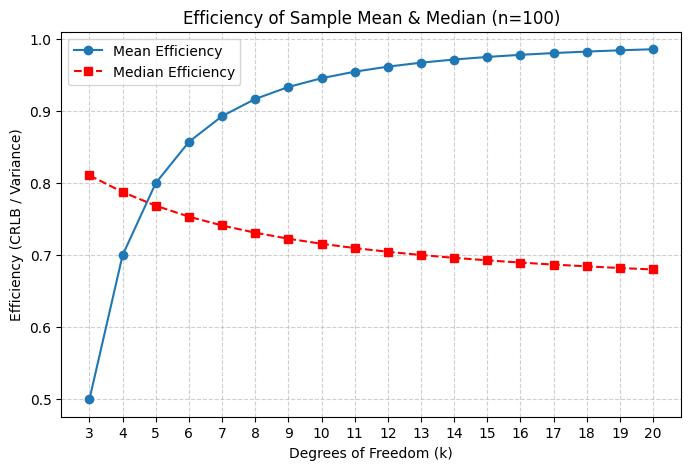

In [12]:
display(fig_efficiency)